In [1]:
import os
import copy
import torch
from pathlib import Path
from stCCL.stCCL.config import set_arg
from stCCL.stCCL.data import *
from stCCL.stCCL.utils import *
from stCCL.stCCL.stCCL import *
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/Mouse Brain (somatosensory cortex)')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stCCL_result/"
#设置参数
opt = set_arg()
# arg = opt.parse_args(['--epoch','450','--n_domain', '7','--radius', '500','--latent_dim','32'])#SpaNCMG设置，无label refine
# arg = opt.parse_args(['--epoch','1000','--n_domain', '11','--radius', '500','--latent_dim','32','--n_refine','30'])
arg = opt.parse_args(['--epoch','1000','--n_domain', '7','--radius', '1000','--latent_dim','32','--n_refine','80'])

print(arg)
sample_name = 'osmFISH_SScortex_mouse'

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=32, log_step=10, lr=0.001, n_domain=7, n_refine=80, radius=1000, seed=0, temp=0.05, weight_decay=0.0001)


=============原始osmFISH_SScortex_mouse切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 6471 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization'
    obsm: 'spatial'
=============Excluding cells后，osmFISH_SScortex_mouse切片信息，带ground truth===============
View of AnnData object with n_obs × n_vars = 4839 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization'
    uns: 'Region_colors'
    obsm: 'spatial'


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Region'}, xlabel='spatial1', ylabel='spatial2'>

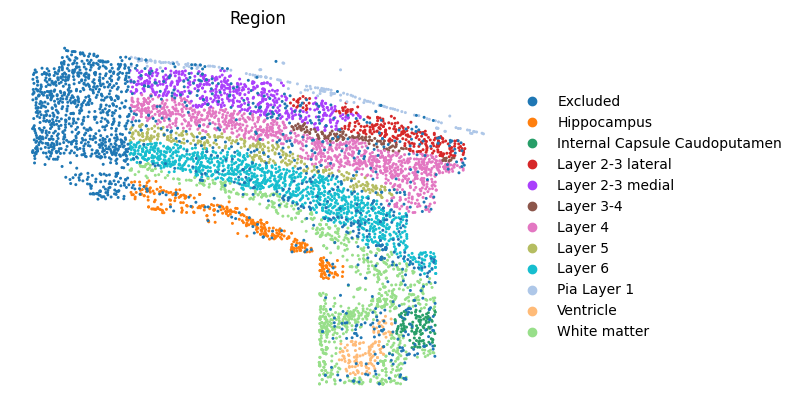

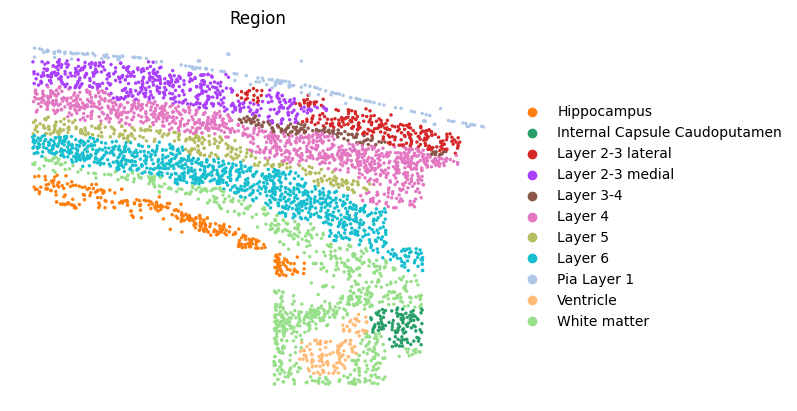

In [3]:
adata = sc.read_loom('/home/ZHX/Dataset/Mouse Brain (somatosensory cortex)/osmFISH_SScortex_mouse_all_cells.loom')#6471 cell 33 genes
adata.obsm['spatial'] = adata.obs[['X','Y']].values
print("=============原始{}切片信息，带ground truth===============".format(sample_name))
print(adata)
sc.pl.embedding(adata,basis='spatial',color=['Region'],show=False, frameon=False)#,save='_osmFISH0.png')

# Excluding cells
used_cells = adata.obs.Region!='Excluded'
adata = adata[used_cells,]#4839 cell 33 genes
print("=============Excluding cells后，{}切片信息，带ground truth===============".format(sample_name))
print(adata)
sc.pl.embedding(adata,basis='spatial',color=['Region'],show=False, frameon=False)#,save='_osmFISH0.png')

=============提取部分层后，osmFISH_SScortex_mouse切片信息，带ground truth===============
View of AnnData object with n_obs × n_vars = 3405 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization'
    uns: 'Region_colors'
    obsm: 'spatial'


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Region'}, xlabel='spatial1', ylabel='spatial2'>

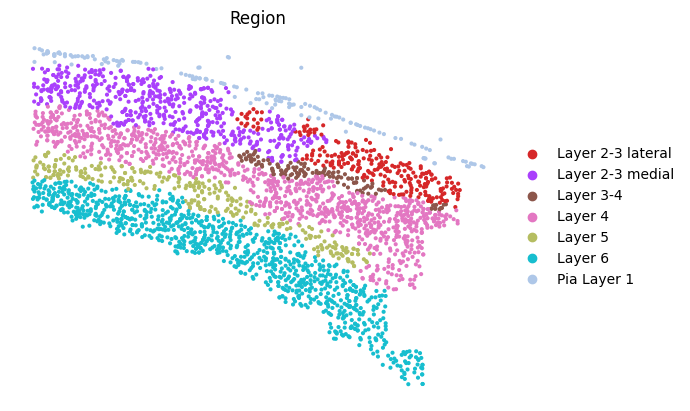

In [4]:
#提取部分层
layer_num_dict = {
    'Pia Layer 1':1,
    'Layer 2-3 lateral':2.5,
    'Layer 2-3 medial':2.5,
    'Layer 3-4':3.5,
    'Layer 4':4,
    'Layer 5':5,
    'Layer 6':6,
}
layer_list = layer_num_dict.keys()
adata_layer = adata[adata.obs['Region'].isin(layer_num_dict.keys())] #3405 cell 33 genes
print("=============提取部分层后，{}切片信息，带ground truth===============".format(sample_name))
print(adata_layer)
sc.pl.embedding(adata_layer,basis='spatial',color=['Region'],show=False, frameon=False)#,save='_osmFISH0.png'

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:151: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": "seurat_v3"}


=============预处理后{}切片信息===============
AnnData object with n_obs × n_vars = 3405 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Region_colors', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3405, 33)
AnnData object with n_obs × n_vars = 3405 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Region_colors', 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj'
Begin

  0%|          | 1/1000 [00:00<02:47,  5.98it/s]

 epoch:  0  feat_loss = 1098.23  loss_sl_1 = 9.86  loss_sl_2 = 4.31  total_loss = 1101.07


 12%|█▏        | 121/1000 [00:01<00:07, 115.86it/s]

...

 82%|████████▏ | 817/1000 [00:07<00:01, 118.41it/s]

 epoch:  800  feat_loss = 4.33  loss_sl_1 = 10.21  loss_sl_2 = 1.12  total_loss = 6.60


 91%|█████████▏| 913/1000 [00:07<00:00, 118.34it/s]

 epoch:  900  feat_loss = 3.80  loss_sl_1 = 9.98  loss_sl_2 = 1.12  total_loss = 6.02


100%|██████████| 1000/1000 [00:08<00:00, 115.66it/s]


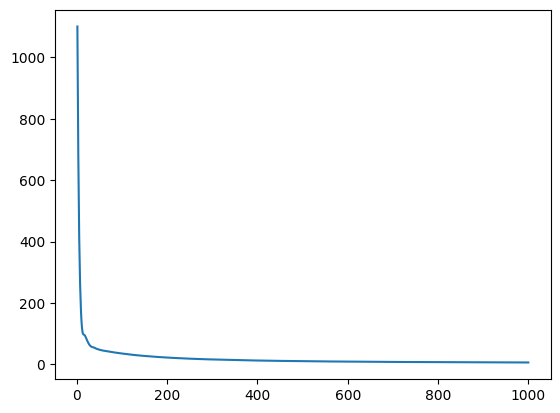

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI = 0.5427
NMI = 0.5844
HS = 0.5806
CS = 0.5882


In [5]:
adata = adata_layer
# # Excluding cells
# used_cells = adata.obs.Region!='Excluded'
# adata = adata[used_cells,]
# sc.pl.embedding(adata,basis='spatial',color=['Region'],show=False, frameon=False)#,save='_osmFISH0.png'

#preprocessing
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
# adata.var['highly_variable']=adata.var_names
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("=============预处理后{}切片信息===============")
print(adata)
#
# # Plot ground truth
# plt.rcParams["figure.figsize"] = (3, 3)
# sc.pl.spatial(adata, img_key="hires", color=["Ground Truth"],show=False)

# train model
adata = train(adata,arg)
print("Completion of training")
# # sc.pp.neighbors(adata, use_rep='SpaNCMG')
# # sc.tl.umap(adata)
# # adata_list_after_training.append(adata)
#     #
#     #
# clustering
# adata = mclust_R(adata, arg.n_domain, used_obsm='stCCL' ,refine=False)
adata = mclust_R(adata, arg.n_domain, used_obsm='stCCL' ,refine=True, n_refine=arg.n_refine)
#
# filter out NA nodes
obs_df = adata.obs.dropna()
ARI = adjusted_rand_score(obs_df['mclust'], obs_df['Region'])
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Region'])
HS = homogeneity_score(adata.obs['Region'],adata.obs['mclust'])
CS = completeness_score(adata.obs['Region'],adata.obs['mclust'])

adata.uns['ARI']=ARI
adata.uns['NMI']=NMI
adata.uns['HS']=HS
adata.uns['CS']=CS
print('ARI = %.4f' %ARI)
print('NMI = %.4f' %NMI)
print('HS = %.4f' %HS)
print('CS = %.4f' %CS)
# adata_list_after_clustering.append(adata)

# print(result_ARI)
# # 计算平均值
# average_ARI = sum(result_ARI) / len(result_ARI)
# print("平均值：", average_ARI)

# result_ARI.append(average_ARI)
# results_df = pd.DataFrame(result_ARI)
# results_df.to_csv(os.path.join(result_path,'MVInfoNCE_mulitiheadattr_test1_osmFISH_SScortex_mouse_all_cells_ARI.csv'))


In [6]:
adata.obs['mclust'].unique()

array(['1', '6', '3', '7', '5', '2', '4'], dtype=object)

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:121: ImplicitModificationWarning: Trying to modify attribute `._uns` 

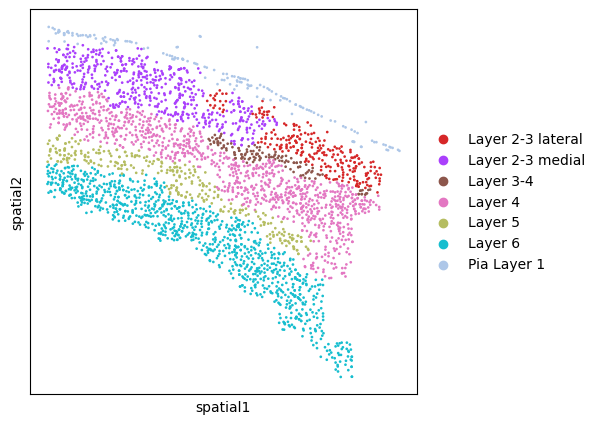

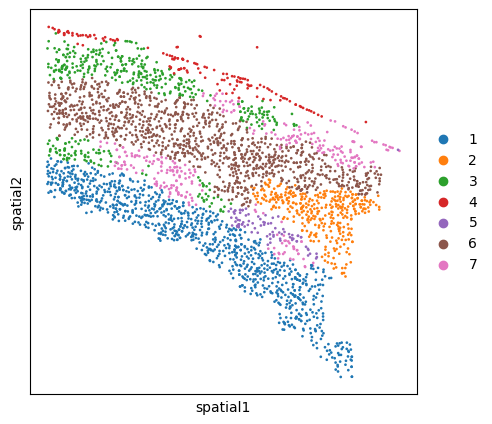

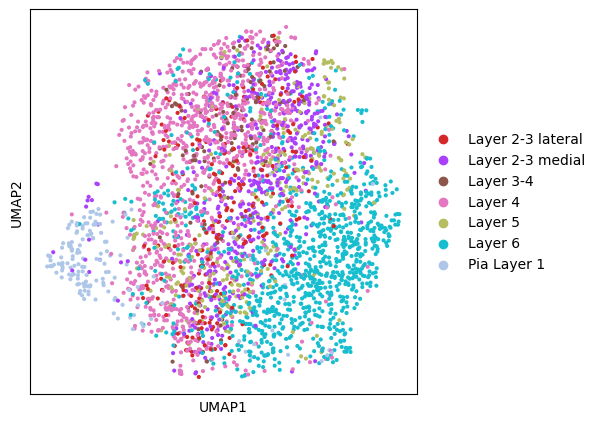

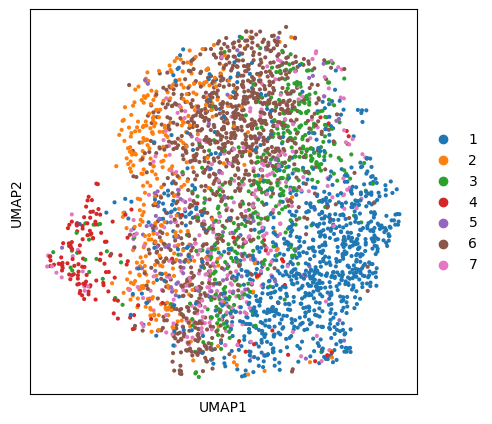

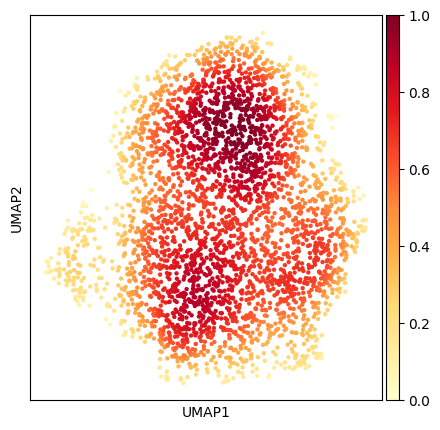

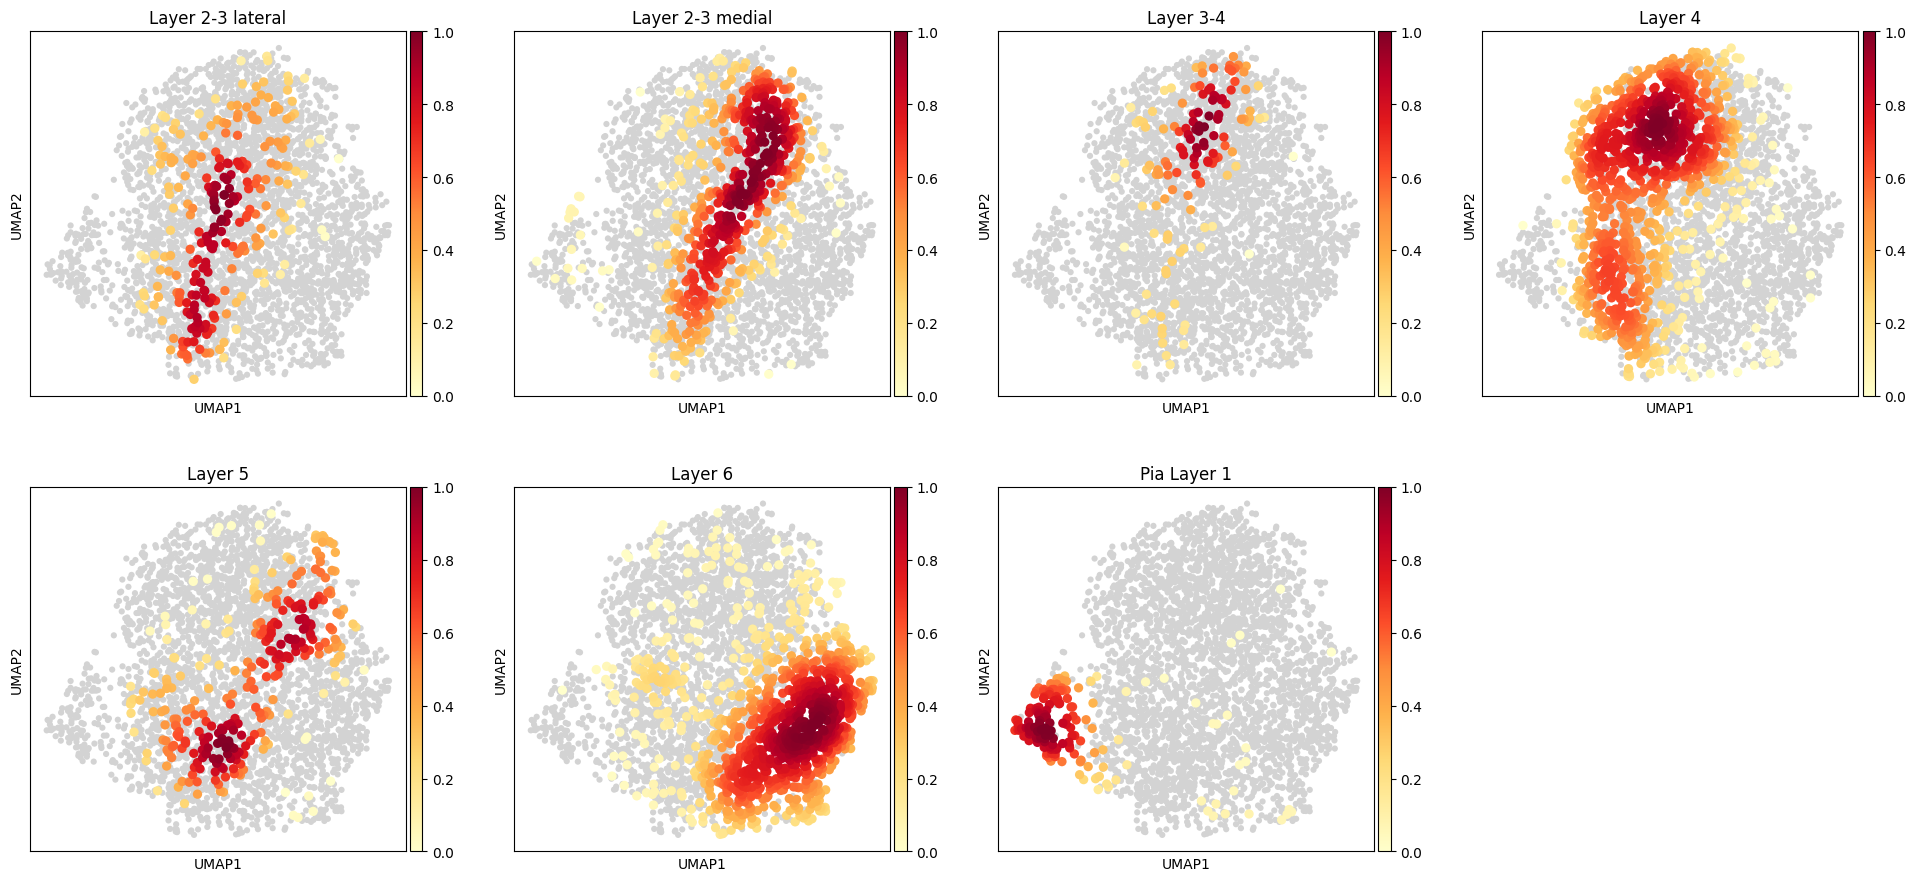

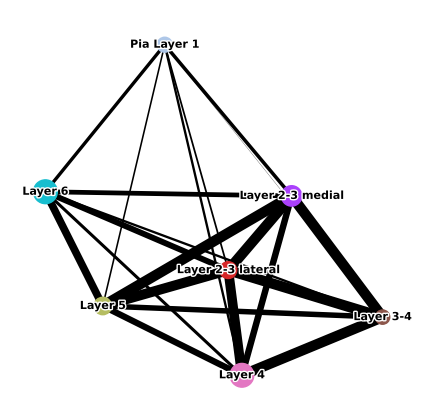

In [7]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)

# fig, axs = plt.subplots(1, 2, figsize=(15, 5))  # 宽度增加，高度不变 # 创建包含两个子图的画布
# sc.pl.embedding(adata, basis="spatial",color="Region", size = 15, title="Ground Truth", ax=axs[0], show=False) # 第一个子图：Ground Truth
# sc.pl.embedding(adata, basis="spatial",color="domain", size = 15, title=f'GraphST (ARI={adata.uns["ARI"]:.4f})', ax=axs[1], show=False) # 第二个子图：mclust结果
# plt.tight_layout(pad=3.0)  # 增加子图之间的间距 # 调整子图间距
# plt.savefig(os.path.join(out_path,"{}_ground truth_ARI.png").format(sample_name))


## spatial architectures
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.embedding(adata,basis="spatial",color="Region", frameon=True,size = 15, title="",show=False)
plt.savefig(os.path.join(out_path,"{}_ground truth.png").format(sample_name),bbox_inches='tight',dpi=300)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.embedding(adata,basis="spatial",color="mclust", frameon=True,size = 15, title="",show=False)
plt.savefig(os.path.join(out_path,"{}_ARI.png").format(sample_name),bbox_inches='tight',dpi=300)


# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='stCCL')
sc.tl.umap(adata)
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.umap(adata,
               color="Region",
               title='',
                frameon=True,
               show=False)
plt.savefig(os.path.join(out_path,"{}_ground_truth_umap.png").format(sample_name),bbox_inches='tight',dpi=300)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
sc.pl.umap(adata,
               color="mclust",
                title='',
               frameon=True,
               # legend_loc='none',
               show=False)
plt.savefig(os.path.join(out_path,"{}_umap.png").format(sample_name),bbox_inches='tight',dpi=300)


## heatmap of density
plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap')
sc.pl.embedding_density(adata, basis='umap', fg_dotsize=40, show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density.png").format(sample_name))

plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap', groupby='Region')
sc.pl.embedding_density(adata, basis='umap', groupby='Region', show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density_by_layer.png").format(sample_name))

## paga trajectory inference
adata = adata[adata.obs['Region'].notna(), :]
sc.tl.paga(adata, groups='Region')
plt.rcParams["figure.figsize"] = (5, 5)
# 绘制标准PAGA图 (替换了paga_compare)
sc.pl.paga(adata,show=False,  frameon=False, fontoutline=2, fontsize=8)
plt.savefig(os.path.join(out_path,"{}_paga.png").format(sample_name),bbox_inches='tight',dpi=300)

# plt.rcParams["figure.figsize"] = (5, 5)
# # 绘制标准PAGA图 (替换了paga_compare)
# sc.pl.paga(adata,show=False, fontsize=10,  fontoutline=2)
# plt.savefig(os.path.join(out_path,"{}_paga_frame.png").format(sample_name),bbox_inches='tight',dpi=300)

# ## paga trajectory inference
# adata = adata[adata.obs['Ground Truth'].notna(), :]
# sc.tl.paga(adata, groups='Ground Truth')
# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=50,
#                    title=adata.obs['slice_id'].unique()[0] + '-stCCL', legend_fontoutline=2, show=False)
# plt.savefig(os.path.join(out_path,"{}_paga.png").format(adata.obs['slice_id'].unique()[0]))


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


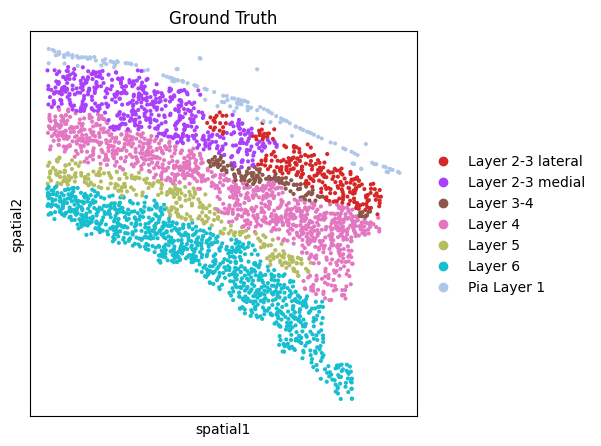

In [8]:
sc.pl.embedding(adata, basis="spatial",color="Region", title="Ground Truth")


In [9]:
adata.obs['Region'].unique()

['Layer 6', 'Layer 4', 'Layer 2-3 medial', 'Layer 5', 'Layer 3-4', 'Layer 2-3 lateral', 'Pia Layer 1']
Categories (7, object): ['Layer 2-3 lateral', 'Layer 2-3 medial', 'Layer 3-4', 'Layer 4', 'Layer 5', 'Layer 6', 'Pia Layer 1']

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Layer 6
Layer 4
Layer 2-3 medial


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Layer 5
Layer 3-4
Layer 2-3 lateral


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Pia Layer 1


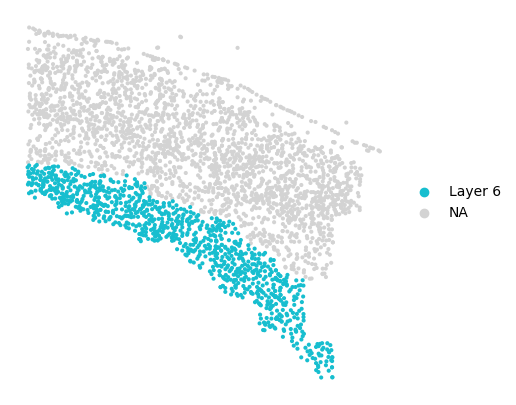

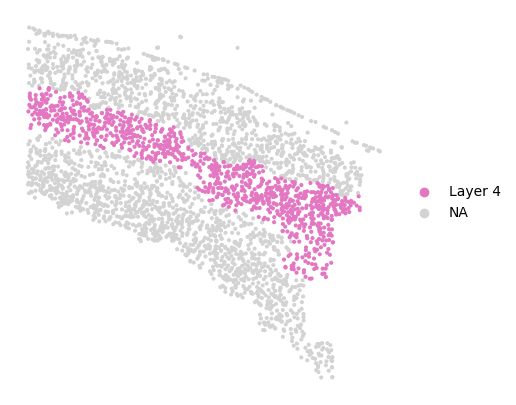

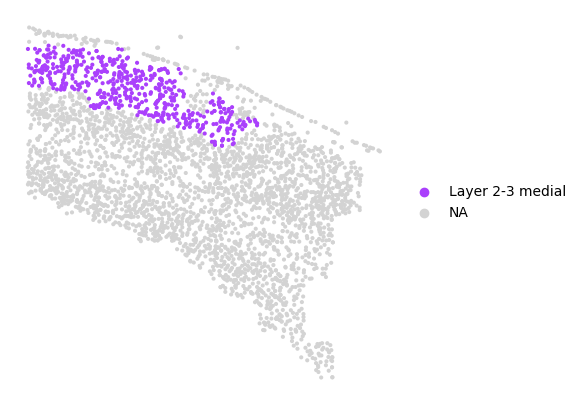

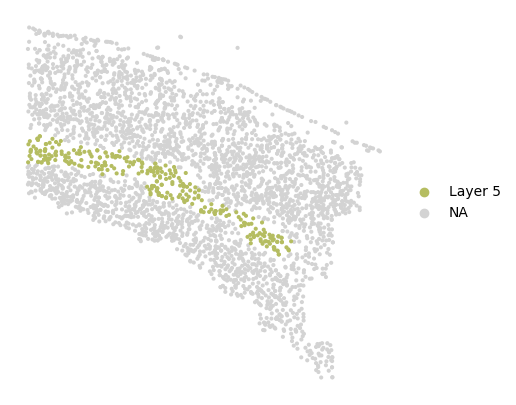

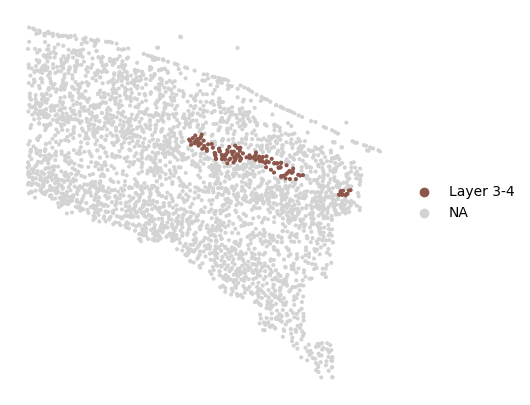

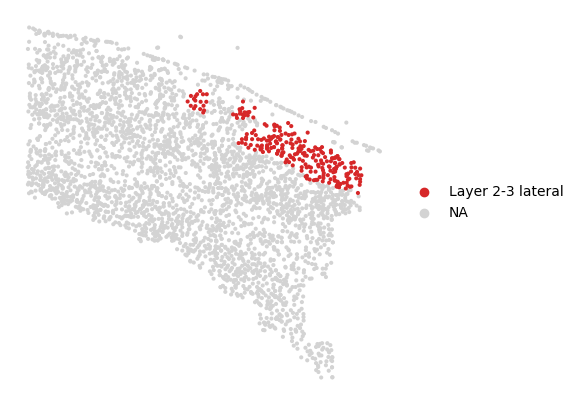

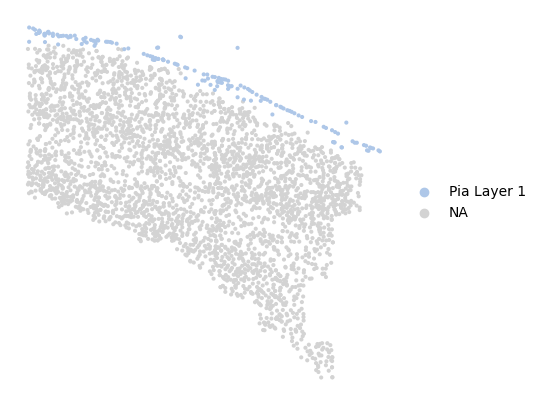

In [10]:
list=adata.obs['Region'].unique()
for i in list:
    print(i)
    sc.pl.embedding(adata, basis="spatial",color="Region", groups=[i], frameon=False,title='',show=False)
    plt.savefig(os.path.join(out_path,"ground_truth_{}.png").format(i))


1
6
3


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


7
5
2


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


4


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


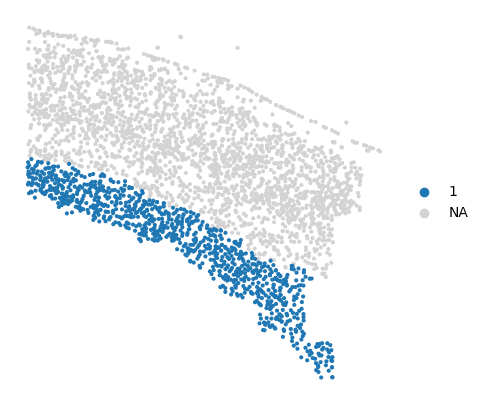

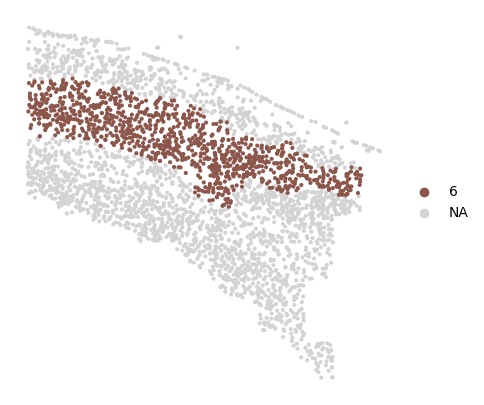

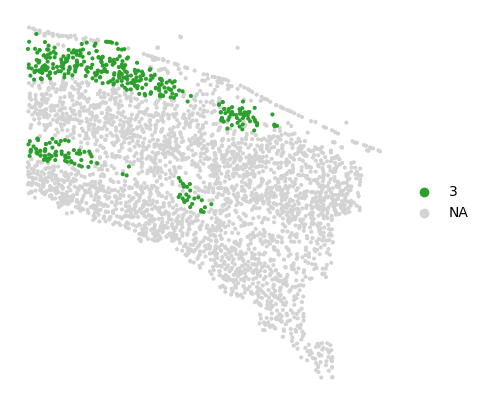

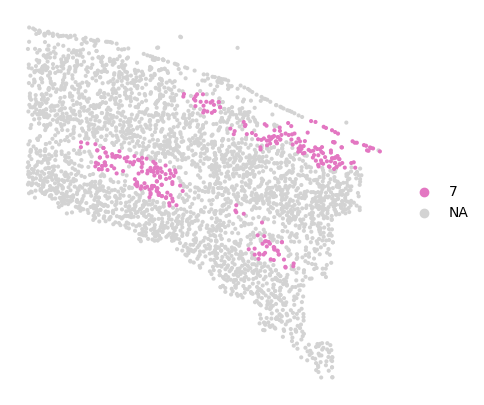

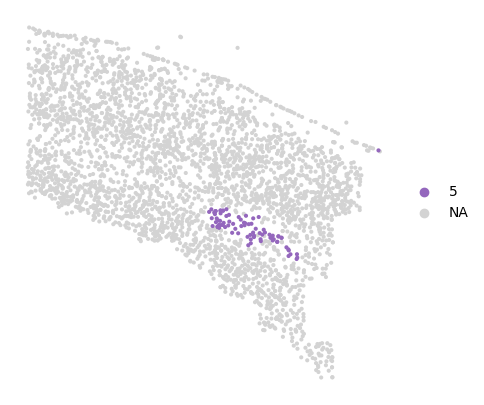

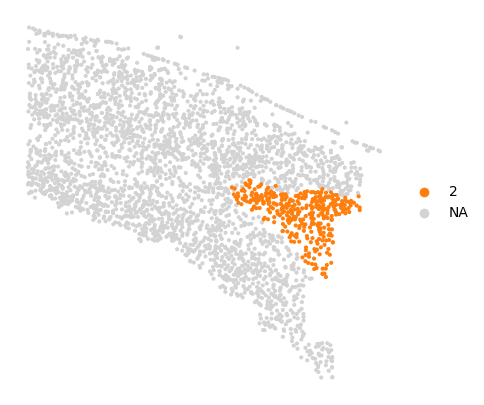

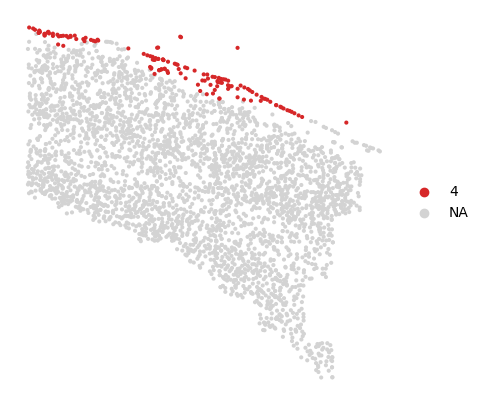

In [11]:
list=adata.obs['mclust'].unique()
for i in list:
    print(i)
    sc.pl.embedding(adata, basis="spatial",color="mclust", groups=[i], frameon=False,title='',show=False)
    plt.savefig(os.path.join(out_path,"cluster_{}.png").format(i))


In [12]:
# 首先进行差异表达分析找到每个簇的标记基因
sc.tl.rank_genes_groups(adata, 'mclust', method='t-test')

# 获取每个簇的标记基因（这里取每个簇的前3个标记基因）
n_top_genes = 8

# 为每个簇创建标记基因可视化
for cluster in adata.obs['mclust'].unique():
    print(f"Cluster {cluster}")

    # 1. 可视化簇的空间分布
    sc.pl.embedding(adata, basis="spatial", color="mclust",
                   groups=[cluster], frameon=False, title=f'Cluster {cluster}', show=False)
    plt.savefig(os.path.join(out_path, f"cluster_{cluster}.png"))
    plt.close()

    # 2. 获取该簇的top标记基因
    top_genes = sc.get.rank_genes_groups_df(adata, group=cluster)[:n_top_genes]['names'].tolist()

    # 3. 可视化每个标记基因的空间表达
    for gene in top_genes:
        if gene in adata.var_names:  # 确保基因存在
            # 创建图形并设置白色背景
            fig, ax = plt.subplots(figsize=(8, 6))
            fig.patch.set_facecolor('white')
            ax.set_facecolor('white')

            # 绘制基因表达图，使用蓝色系颜色映射
            sc.pl.embedding(adata, basis="spatial", color=gene,
                            title='',
                            frameon=False,
                            # legend_loc='none',
                           # title=f'{gene} in Cluster {cluster}',
                           cmap='viridis', show=False, ax=ax)

            # 保存图像
            plt.savefig(os.path.join(out_path, f"cluster_{cluster}_gene_{gene}.png"),
                       bbox_inches='tight', facecolor='white')
            plt.close()
        else:
            print(f"Warning: Gene {gene} not found in var_names")

# # 可选：保存标记基因结果到文件
# marker_genes_df = sc.get.rank_genes_groups_df(adata, group=None)
# marker_genes_df.to_csv(os.path.join(out_path, "marker_genes_all_clusters.csv"))
#
# # 可选：绘制所有簇的标记基因热图
# sc.pl.rank_genes_groups_heatmap(adata,
#                                groups=adata.obs['mclust'].unique().tolist(),
#                                n_genes=5,
#                                show_gene_labels=True,
#                                show=False)
# # 设置热图背景为白色
# plt.gcf().set_facecolor('white')
# plt.savefig(os.path.join(out_path, "marker_genes_heatmap.png"),
#            bbox_inches='tight', facecolor='white')
# plt.close()

Cluster 1


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 6


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 3


...

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 2


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 4


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
